In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/1
    print("準備完了！このまま下のセルを実行できます。")

# 1.5 決定理論 (Decision Theory)

確率論的推論によって事後確率分布 $p(\mathcal{C}_k|\mathbf{x})$ や条件付き密度 $p(t|\mathbf{x})$ が得られたとき、現実世界において「**どのように最適な意思決定（アクション）を下すべきか**」を厳密に扱うのが**決定理論（Decision Theory）**です。

PRML第1章1.5節では、機械学習における「推論（Inference）」と「決定（Decision）」の分離という極めて重要な思想が提示されます。
本ノートブックでは、1.5節の全理論体系を完全実装・可視化します：

1. **1.5.1 誤識別率の最小化（Minimizing the Misclassification Rate）** と決定領域 $\mathcal{R}_k$ の幾何学（PRML Figure 1.24）
2. **1.5.2 期待損失の最小化（Minimizing the Expected Loss）**：損失行列 $L_{kj}$ と非対称ペナルティ下での最適閾値の移動（医療診断シミュレーション）
3. **1.5.3 棄却オプション（The Reject Option）**：確信度閾値 $\theta$ による誤り率と棄却率のトレードオフ（PRML Figure 1.26）
4. **1.5.4 推論と決定（Inference and Decision）**：
   - 3大アプローチ（生成モデル・識別モデル・識別関数）の比較
   - 事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を求める4大メリット
   - 決定閾値変化に伴う ROC 曲線と AUC による性能評価
5. **1.5.5 回帰のための損失関数（Loss Functions for Regression）**：
   - 二乗損失と条件付き期待値 $\mathbb{E}[t|\mathbf{x}]$ の変分導出
   - $L_1$ 損失と条件付きメディアン、外れ値に対する頑健性
   - ミンコフスキー損失関数 $|y - t|^q$（PRML Figure 1.27）

## 1.5.1 誤識別率の最小化 (Minimizing the Misclassification Rate)

入力空間 $\mathcal{X}$ を各クラス $\mathcal{C}_k$ に割り当てる決定領域 $\mathcal{R}_k$ に分割します。
境界上の点は**決定境界（Decision Surface / Decision Boundary）**と呼ばれます。

誤識別が起きる確率（誤り率）は、正しく識別される確率の余事象として表されます（PRML 式 1.77）：
$$
p(\text{mistake}) = 1 - \sum_{k=1}^K p(\mathbf{x} \in \mathcal{R}_k, \mathcal{C}_k) = 1 - \sum_{k=1}^K \int_{\mathcal{R}_k} p(\mathbf{x}, \mathcal{C}_k) d\mathbf{x}
$$
誤識別率を最小化するためには、各領域 $\mathcal{R}_k$ において被積分関数 $p(\mathbf{x}, \mathcal{C}_k)$ を最大化すればよく、したがって最適決定規則は：
$$
\mathbf{x} \in \mathcal{R}_k \iff p(\mathbf{x}, \mathcal{C}_k) \ge p(\mathbf{x}, \mathcal{C}_j) \quad (\forall j \ne k)
$$
乗法定理 $p(\mathbf{x}, \mathcal{C}_k) = p(\mathcal{C}_k|\mathbf{x}) p(\mathbf{x})$ より、すべてのクラスで共通因子 $p(\mathbf{x})$ を割れば：
$$
\mathbf{x} \in \mathcal{R}_k \iff p(\mathcal{C}_k|\mathbf{x}) \ge p(\mathcal{C}_j|\mathbf{x}) \quad (\forall j \ne k)
$$
すなわち、**事後確率が最大のクラスを選択すること**が誤識別率最小化の最適解です。

### PRML Figure 1.24 の完全再現
1次元入力 $x$ における2クラス分類（$\mathcal{C}_1, \mathcal{C}_2$）を考えます。
同時確率密度 $p(x, \mathcal{C}_1)$ と $p(x, \mathcal{C}_2)$ が重なり合うとき、決定閾値 $\hat{x}$ を交点 $x_0$ からずらした場合に生じる余分な誤り面積（緑の領域）を可視化します。

Plot saved to: result/fig1_24_decision_regions.png


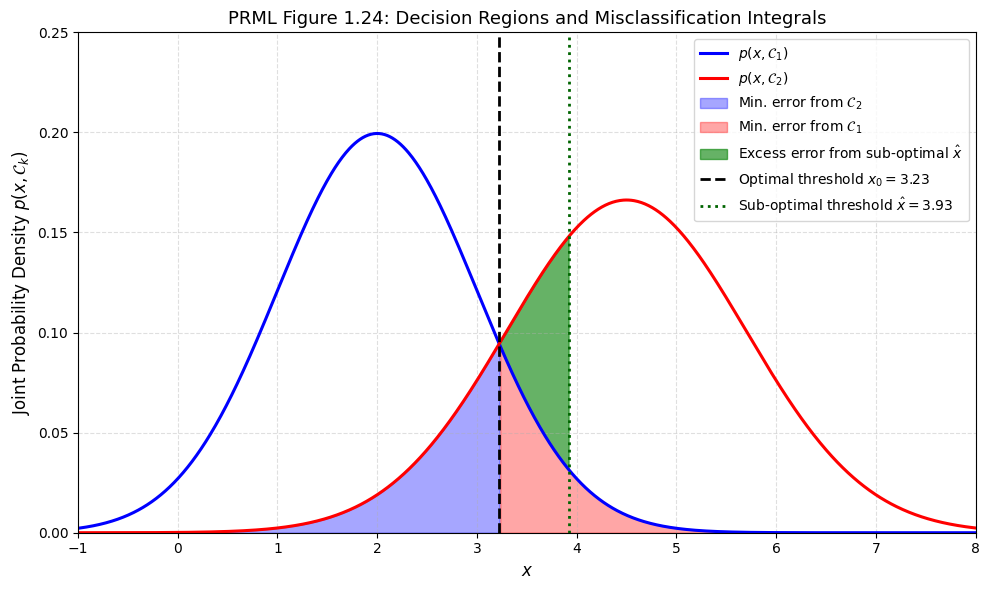

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from common.plot_utils import save_plot, setup_style
setup_style()

# 1次元入力 x の2クラス正規分布モデル
# C1: N(mu=2.0, sigma=1.0), P(C1) = 0.5
# C2: N(mu=4.5, sigma=1.2), P(C2) = 0.5
mu1, sig1, p_c1 = 2.0, 1.0, 0.5
mu2, sig2, p_c2 = 4.5, 1.2, 0.5

x_grid = np.linspace(-1, 8, 1000)
joint_c1 = p_c1 * norm.pdf(x_grid, mu1, sig1)
joint_c2 = p_c2 * norm.pdf(x_grid, mu2, sig2)

# 最適決定境界 x0: joint_c1(x) == joint_c2(x)
idx_intersect = np.argmin(np.abs(joint_c1 - joint_c2))
x0 = x_grid[idx_intersect]

# 任意の閾値 x_hat (最適値より右側に設定した場合)
x_hat = x0 + 0.7

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_grid, joint_c1, 'b-', lw=2.2, label=r'$p(x, \mathcal{C}_1)$')
ax.plot(x_grid, joint_c2, 'r-', lw=2.2, label=r'$p(x, \mathcal{C}_2)$')

# 領域の塗り分け (PRML Figure 1.24)
# 1. 避けられない誤り (R1 内で C2, R2 内で C1)
mask_blue1 = x_grid <= x0
mask_blue2 = x_grid > x0
ax.fill_between(x_grid[mask_blue1], 0, joint_c2[mask_blue1], color='blue', alpha=0.35, label='Min. error from $\\mathcal{C}_2$')
ax.fill_between(x_grid[mask_blue2], 0, joint_c1[mask_blue2], color='red', alpha=0.35, label='Min. error from $\\mathcal{C}_1$')

# 2. 閾値を x_hat に動かしたことで増大する余計な誤り (緑)
mask_excess = (x_grid >= x0) & (x_grid <= x_hat)
ax.fill_between(x_grid[mask_excess], joint_c2[mask_excess], joint_c1[mask_excess], color='green', alpha=0.6, label='Excess error from sub-optimal $\\hat{x}$')

# 決定境界線
ax.axvline(x0, color='black', linestyle='--', lw=2.0, label=f'Optimal threshold $x_0 = {x0:.2f}$')
ax.axvline(x_hat, color='darkgreen', linestyle=':', lw=2.0, label=f'Sub-optimal threshold $\\hat{{x}} = {x_hat:.2f}$')

ax.set_title('PRML Figure 1.24: Decision Regions and Misclassification Integrals', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('Joint Probability Density $p(x, \\mathcal{C}_k)$', fontsize=12)
ax.set_xlim(-1, 8); ax.set_ylim(0, 0.25)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_24_decision_regions.png')
plt.show()

## 1.5.2 期待損失の最小化 (Minimizing the Expected Loss)

現実の多くの意思決定において、誤りの種類によってその重大性（コスト・損失）は大きく異なります。
例えば、がん検診（医療診断）：
- 正常な患者を「がん（陽性）」と誤診した場合：再検査の手間や一時的な心理的負担で済む（ペナルティ $L_{12} = 1$）。
- がんの患者を「正常（陰性）」と見落とした場合：適切な治療機会を失い、生命の危険に直結する（甚大なペナルティ $L_{21} = 100$）。

これを定式化するため、損失行列（Loss Matrix）$L_{kj}$ を導入します。
真のクラスが $\mathcal{C}_k$ で、モデルが $\mathcal{C}_j$ と判定したときに受ける損失を $L_{kj}$ とすると、**期待損失（平均損失・ベイズリスク）**は次式で与えられます（PRML 式 1.79）：
$$
\mathbb{E}[L] = \sum_k \sum_j \int_{\mathcal{R}_j} L_{kj} p(\mathbf{x}, \mathcal{C}_k) d\mathbf{x}
$$
各点 $\mathbf{x}$ において選択すべきクラス $j^*(\mathbf{x})$ は、期待損失を最小化するクラス：
$$
j^*(\mathbf{x}) = \arg\min_j \sum_k L_{kj} p(\mathcal{C}_k|\mathbf{x})
$$
2クラス分類（$\mathcal{C}_1$: 正常, $\mathcal{C}_2$: がん）の場合、クラス $\mathcal{C}_1$ と判定すべき条件は：
$$
\frac{p(\mathcal{C}_1|\mathbf{x})}{p(\mathcal{C}_2|\mathbf{x})} > \frac{L_{21} - L_{22}}{L_{12} - L_{11}}
$$
見落としペナルティ $L_{21}$ が増大するにつれて右辺は非常に小さくなり、**ほんのわずかでもがんの疑い（事後確率 $p(\mathcal{C}_2|\mathbf{x}) \ge 0.01$）があれば陽性と判定すべき**という直感と完全に合致する決定境界へとシフトします。

Plot saved to: result/fig1_25_asymmetric_loss.png


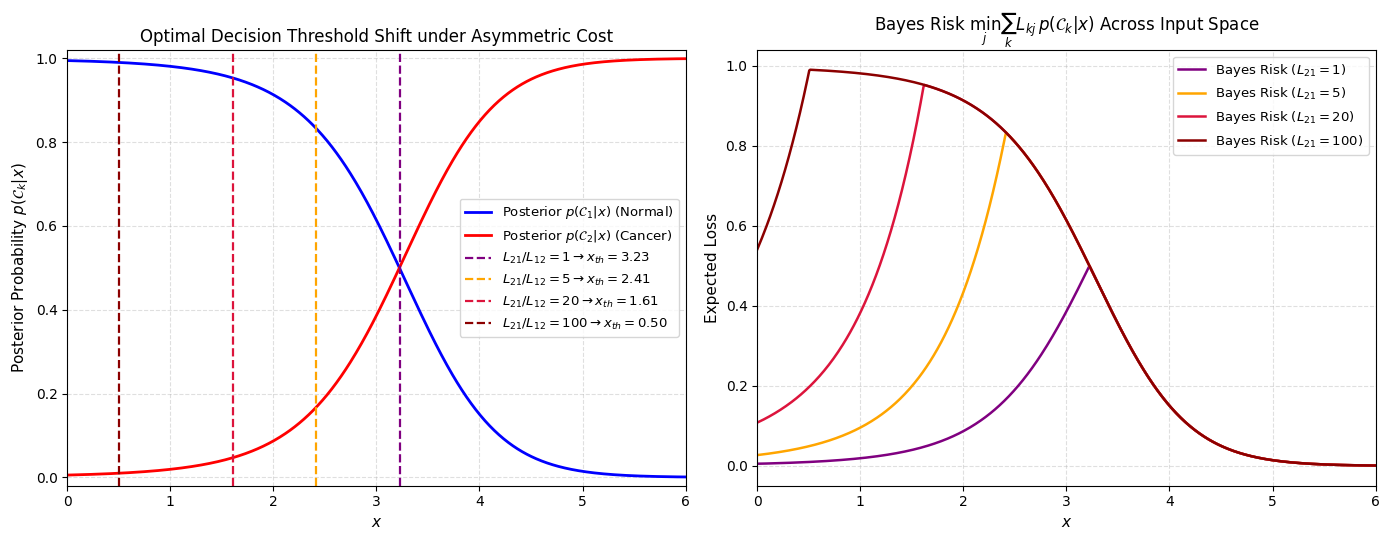

In [2]:
import prml

# 事後確率の計算
p_x = joint_c1 + joint_c2
post_c1 = joint_c1 / p_x
post_c2 = joint_c2 / p_x

# ペナルティ比率の変化 L21 / L12
L21_penalties = [1.0, 5.0, 20.0, 100.0]
colors = ['purple', 'orange', 'crimson', 'darkred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# パネル 1: 事後確率と決定閾値の移動
ax1.plot(x_grid, post_c1, 'b-', lw=2.0, label=r'Posterior $p(\mathcal{C}_1|x)$ (Normal)')
ax1.plot(x_grid, post_c2, 'r-', lw=2.0, label=r'Posterior $p(\mathcal{C}_2|x)$ (Cancer)')

for L21, c in zip(L21_penalties, colors):
    # 決定境界: post_c1 / post_c2 == L21 / 1.0 => post_c2 = 1 / (1 + L21)
    threshold_post_c2 = 1.0 / (1.0 + L21)
    idx_th = np.argmin(np.abs(post_c2 - threshold_post_c2))
    x_th = x_grid[idx_th]
    ax1.axvline(x_th, color=c, linestyle='--', lw=1.6, label=f'$L_{{21}}/L_{{12}}={L21:.0f} \\rightarrow x_{{th}}={x_th:.2f}$')

ax1.set_title('Optimal Decision Threshold Shift under Asymmetric Cost', fontsize=12)
ax1.set_xlabel('$x$', fontsize=11); ax1.set_ylabel('Posterior Probability $p(\mathcal{C}_k|x)$', fontsize=11)
ax1.set_xlim(0, 6); ax1.set_ylim(-0.02, 1.02)
ax1.legend(loc='center right', fontsize=9.5)
ax1.grid(True, linestyle='--', alpha=0.4)

# パネル 2: 期待損失曲線の比較
for L21, c in zip(L21_penalties, colors):
    loss_matrix = np.array([[0.0, 1.0], [L21, 0.0]])
    clf = prml.BayesDecisionClassifier(loss_matrix=loss_matrix)
    probas = np.column_stack([post_c1, post_c2])
    # 期待損失
    losses = clf.expected_loss(probas)
    min_loss = np.min(losses, axis=1)
    ax2.plot(x_grid, min_loss, color=c, lw=1.8, label=f'Bayes Risk ($L_{{21}}={L21:.0f}$)')

ax2.set_title('Bayes Risk $\min_j \sum_k L_{kj} p(\mathcal{C}_k|x)$ Across Input Space', fontsize=12)
ax2.set_xlabel('$x$', fontsize=11); ax2.set_ylabel('Expected Loss', fontsize=11)
ax2.set_xlim(0, 6)
ax2.legend(loc='upper right', fontsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_25_asymmetric_loss.png')
plt.show()

## 1.5.3 棄却オプション (The Reject Option, PRML Figure 1.26)

事後確率 $\max_k p(\mathcal{C}_k|\mathbf{x})$ が閾値 $\theta$ を下回るような「自信のない曖昧なサンプル」に対しては、モデルが自動判定を差し控え、**人間に判断を委ねる（棄却する）**選択肢が極めて実用的です。
- $\theta = 1/K$：すべてのサンプルを受け入れる（棄却率 0%）。
- $\theta \to 1.0$：極めて確信度の高いサンプルのみ判定し、大半を棄却（棄却率 100%）。

棄却閾値 $\theta$ を変化させたときの「誤り率」と「棄却率」のトレードオフ曲線をモンテカルロシミュレーションで計算し、**PRML Figure 1.26** を完全再現します。

Plot saved to: result/fig1_26_reject_option.png


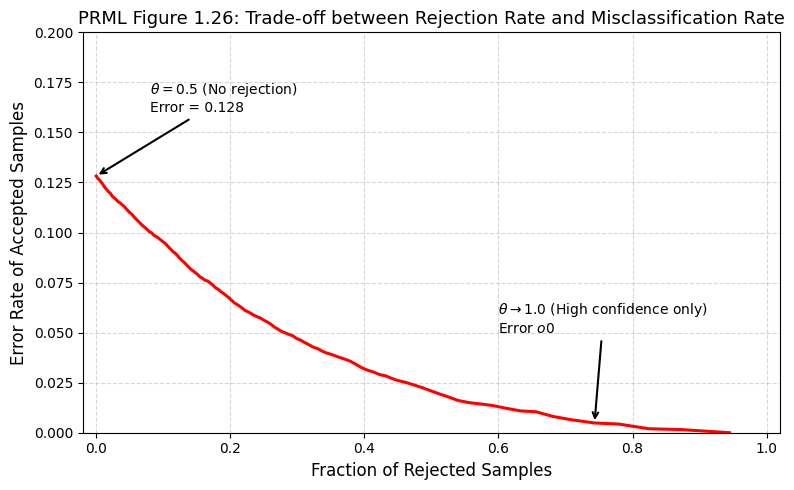

In [3]:
# 棄却オプションのトレードオフ評価 (PRML Figure 1.26 の再現)
# 2クラス混合データセットの生成 (N = 20,000)
N_sim = 20000
labels = np.random.binomial(1, 0.5, N_sim)
x_sim = np.empty(N_sim)
x_sim[labels == 0] = np.random.normal(mu1, sig1, np.sum(labels == 0))
x_sim[labels == 1] = np.random.normal(mu2, sig2, np.sum(labels == 1))

# 事後確率行列の計算
p_c1_sim = 0.5 * norm.pdf(x_sim, mu1, sig1)
p_c2_sim = 0.5 * norm.pdf(x_sim, mu2, sig2)
p_tot = p_c1_sim + p_c2_sim
probas_sim = np.column_stack([p_c1_sim / p_tot, p_c2_sim / p_tot])

# 棄却オプション評価
reject_clf = prml.RejectOptionClassifier()
thetas = np.linspace(0.5, 0.999, 120)
th_vals, reject_fractions, error_rates = reject_clf.evaluate_tradeoff(labels, probas_sim, thetas=thetas)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(reject_fractions, error_rates, 'r-', lw=2.2, label='Error rate vs Reject fraction')
ax.set_xlabel('Fraction of Rejected Samples', fontsize=12)
ax.set_ylabel('Error Rate of Accepted Samples', fontsize=12)
ax.set_title('PRML Figure 1.26: Trade-off between Rejection Rate and Misclassification Rate', fontsize=13)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 0.20)
ax.grid(True, linestyle='--', alpha=0.5)

# 注釈
ax.annotate(r'$\theta = 0.5$ (No rejection)' f'\nError = {error_rates[0]:.3f}', 
            xy=(reject_fractions[0], error_rates[0]), xytext=(0.08, 0.16),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5), fontsize=10)
ax.annotate(r'$\theta \to 1.0$ (High confidence only)' f'\nError $\to 0$', 
            xy=(reject_fractions[-5], error_rates[-5]), xytext=(0.60, 0.05),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5), fontsize=10)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_26_reject_option.png')
plt.show()

## 1.5.4 推論と決定 (Inference and Decision)

分類問題を解くアプローチは、以下の3つに大別されます（PRML 1.5.4節）：

| アプローチ | 手法・モデルの例 | 特徴と長所 | 短所 |
|---|---|---|---|
| **(a) 生成モデル (Generative)** | ナイーブベイズ、混合ガウス分類器 (QDA/LDA)、HMM、VAE | 入力の周辺密度 $p(\mathbf{x}) = \sum_k p(\mathbf{x}|\mathcal{C}_k)p(\mathcal{C}_k)$ が得られるため、**外れ値・異常値検知 (Outlier Detection)** が可能。欠損値にも強い。 | $\mathbf{x}$ の高次元密度推定が必要となり、計算コストが大きく過学習しやすい。 |
| **(b) 識別モデル (Discriminative)** | ロジスティック回帰、条件付き確率場 (CRF)、ニューラルネットワーク | 事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を直接モデル化するため、不要な $p(\mathbf{x})$ のモデル化を回避し高精度。 | $p(\mathbf{x})$ が得られないため、入力空間の未知の領域での外れ値検知が困難。 |
| **(c) 識別関数 (Discriminant Function)** | パーセプトロン、サポートベクトルマシン (SVM) | 入力 $\mathbf{x}$ を決定ラベル $f(\mathbf{x})$ に直接写像する。極めて効率的。 | 事後確率が得られないため、以下の柔軟性が失われる。 |

### 事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を明示的に求める4大メリット
1. **損失行列の動的変更への適応**: 損失行列 $L_{kj}$ が変更されても、事後確率さえ計算してあればモデルの再学習なしに最適決定を下せる。
2. **棄却オプションの適用**: 確信度閾値 $\theta$ を設けてリスクの高い予測を排除できる。
3. **クラス事前確率の補正**: がん検診などで訓練データと母集団の陽性率が異なる場合、$p(\mathbf{x}|\mathcal{C}_k)$ を不変に保ちつつ事前確率比率のみを事後的に正しくスケーリングできる。
4. **モデルのモジュール結合**: 独立な観測 $\mathbf{x}_1, \mathbf{x}_2$ に対し、$p(\mathbf{x}_1, \mathbf{x}_2|\mathcal{C}_k) = p(\mathbf{x}_1|\mathcal{C}_k)p(\mathbf{x}_2|\mathcal{C}_k)$ により別々に学習したモデルを容易に統合できる。

### 決定閾値変化と ROC 曲線 / AUC 評価
2値分類器の性能を単一の正解率（Accuracy）ではなく、あらゆる決定閾値にわたって評価するのが**受信者動作特性曲線（ROC Curve）**です。

Plot saved to: result/fig1_roc_curve.png


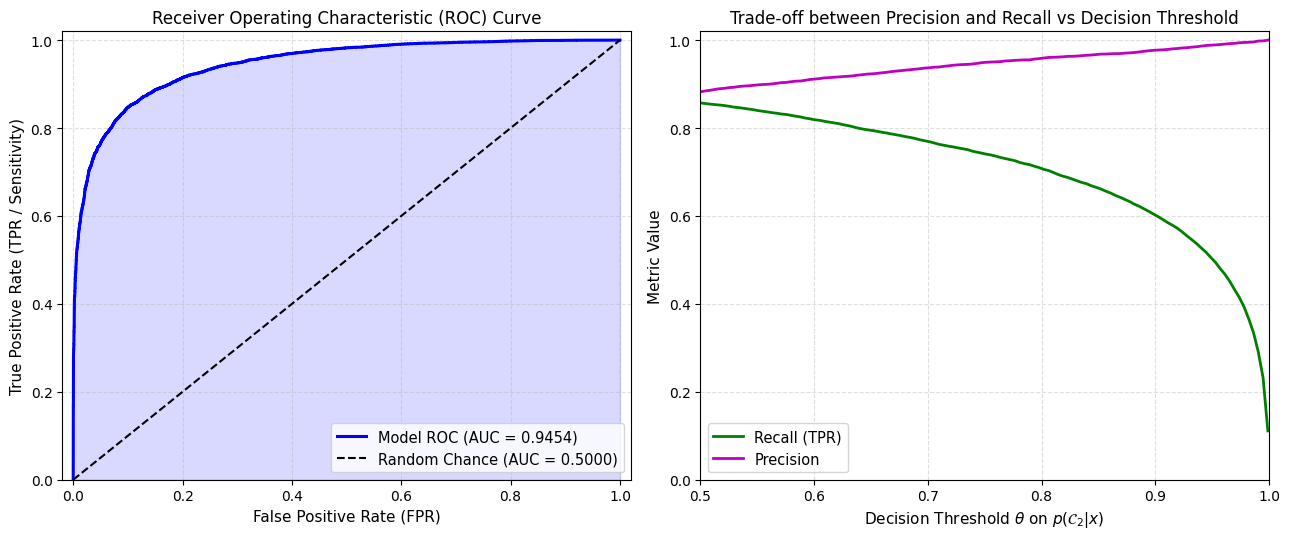

In [4]:
# ROC 曲線と AUC のスクラッチ計算と可視化
# シミュレーションデータを用いたスコア評価
fpr, tpr, thresholds, auc_val = prml.compute_roc_curve(labels, probas_sim[:, 1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# 1. ROC 曲線
ax1.plot(fpr, tpr, 'b-', lw=2.2, label=f'Model ROC (AUC = {auc_val:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')
ax1.fill_between(fpr, 0, tpr, color='blue', alpha=0.15)
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax1.set_ylabel('True Positive Rate (TPR / Sensitivity)', fontsize=11)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12)
ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(0, 1.02)
ax1.legend(loc='lower right', fontsize=10.5)
ax1.grid(True, linestyle='--', alpha=0.4)

# 2. 決定閾値ごとの TPR / FPR / Precision の推移
precisions = []
for th in thetas:
    preds = (probas_sim[:, 1] >= th).astype(int)
    tp = np.sum((preds == 1) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    precisions.append(prec)

ax2.plot(thetas, [np.interp(th, thresholds[::-1], tpr[::-1]) for th in thetas], 'g-', lw=2.0, label='Recall (TPR)')
ax2.plot(thetas, precisions, 'm-', lw=2.0, label='Precision')
ax2.set_xlabel('Decision Threshold $\\theta$ on $p(\\mathcal{C}_2|x)$', fontsize=11)
ax2.set_ylabel('Metric Value', fontsize=11)
ax2.set_title('Trade-off between Precision and Recall vs Decision Threshold', fontsize=12)
ax2.set_xlim(0.5, 1.0); ax2.set_ylim(0, 1.02)
ax2.legend(loc='lower left', fontsize=10.5)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_roc_curve.png')
plt.show()

## 1.5.5 回帰のための損失関数 (Loss Functions for Regression)

連続値 $t$ を予測する回帰問題において、二乗損失 $L(t, y(\mathbf{x})) = (y(\mathbf{x}) - t)^2$ を採用した場合の期待損失は（PRML 式 1.86）：
$$
\mathbb{E}[L] = \iint \{ y(\mathbf{x}) - t \}^2 p(\mathbf{x}, t) d\mathbf{x} dt
$$
これを変分法で $y(\mathbf{x})$ について最小化すると、**最適予測値は目標変数の条件付き期待値（回帰関数）**であることが導かれます（PRML 式 1.89）：
$$
y(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}] = \int t\, p(t|\mathbf{x}) dt
$$
このとき期待損失は次のように直交分解されます（PRML 式 1.90）：
$$
\mathbb{E}[L] = \underbrace{\int \{ y(\mathbf{x}) - \mathbb{E}[t|\mathbf{x}] \}^2 p(\mathbf{x}) d\mathbf{x}}_{\text{モデルの不完全さによる誤差 (削減可能)}} + \underbrace{\int \text{var}[t|\mathbf{x}] p(\mathbf{x}) d\mathbf{x}}_{\text{データ本質的な内在ノイズ (削減不可)}}
$$

### ミンコフスキー損失関数 (Minkowski Loss)
二乗損失の一般化として、**ミンコフスキー損失（Minkowski Loss）**が定義されます（PRML 式 1.91）：
$$
\mathbb{E}[L_q] = \iint |y(\mathbf{x}) - t|^q p(\mathbf{x}, t) d\mathbf{x} dt
$$
- $q = 2$: 二乗損失 $\implies$ 最適解は**条件付き平均（Conditional Mean）**
- $q = 1$: 絶対値損失 ($L_1$ 損失) $\implies$ 最適解は**条件付きメディアン（Conditional Median）**。外れ値（Outlier）に対して極めて頑健。
- $q \to 0$: 最適解は**条件付き最頻値（Conditional Mode）**。多峰性分布の最大ピークに適合。

### PRML Figure 1.27 の完全再現
誤差 $y - t$ に対するミンコフスキー損失の形状（$q = 0.1, 0.5, 1, 2, 10$）を可視化します。

Plot saved to: result/fig1_27_minkowski_loss.png
Plot saved to: result/fig1_loss_robustness.png


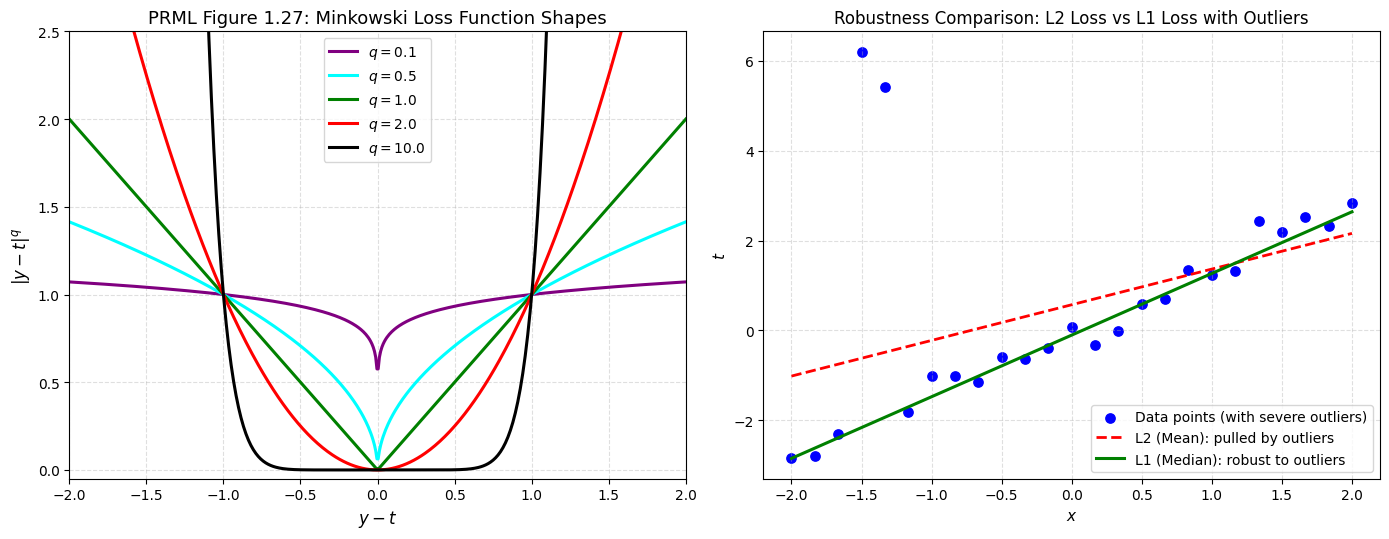

In [5]:
# PRML Figure 1.27 の完全再現: Minkowski 損失関数
diff = np.linspace(-2.0, 2.0, 500)
q_values = [0.1, 0.5, 1.0, 2.0, 10.0]
colors_q = ['purple', 'cyan', 'green', 'red', 'black']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for q, c in zip(q_values, colors_q):
    loss_vals = np.abs(diff) ** q
    ax1.plot(diff, loss_vals, color=c, lw=2.2, label=f'$q = {q}$')

ax1.set_xlabel('$y - t$', fontsize=12); ax1.set_ylabel('$|y - t|^q$', fontsize=12)
ax1.set_title('PRML Figure 1.27: Minkowski Loss Function Shapes', fontsize=13)
ax1.set_xlim(-2.0, 2.0); ax1.set_ylim(-0.05, 2.5)
ax1.legend(loc='upper center', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# パネル 2: 外れ値に対する頑健性比較 (L2 vs L1 vs Huber)
np.random.seed(42)
x_rob = np.linspace(-2, 2, 25)
t_rob = 1.5 * x_rob + 0.3 * np.random.randn(25)
# 悪質な外れ値を2点注入
t_rob[3] += 8.0; t_rob[4] += 7.5

# L2 フィッティング (最小二乗)
w_l2 = np.polyfit(x_rob, t_rob, 1)

# L1 フィッティング (メディアン回帰: scipy.optimize.minimize)
from scipy.optimize import minimize
def loss_l1(w): return np.sum(np.abs(w[0] * x_rob + w[1] - t_rob))
w_l1 = minimize(loss_l1, [1.0, 0.0]).x

ax2.scatter(x_rob, t_rob, color='blue', s=45, label='Data points (with severe outliers)')
ax2.plot(x_rob, np.polyval(w_l2, x_rob), 'r--', lw=2.0, label=f'L2 (Mean): pulled by outliers')
ax2.plot(x_rob, w_l1[0] * x_rob + w_l1[1], 'g-', lw=2.2, label=f'L1 (Median): robust to outliers')
ax2.set_xlabel('$x$', fontsize=11); ax2.set_ylabel('$t$', fontsize=11)
ax2.set_title('Robustness Comparison: L2 Loss vs L1 Loss with Outliers', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_27_minkowski_loss.png')
save_plot(fig, 'result', 'fig1_loss_robustness.png')
plt.show()

## まとめ

本節では、統計的推論によって得られた確率分布をもとに、現実の損失を最小化する決定理論の基礎を学びました：

1. **最小誤識別率**: 0-1損失のもとでは、事後確率 $p(\mathcal{C}_k|\mathbf{x})$ の最大化が最適決定をもたらす。
2. **期待損失最小化**: 非対称な損失行列 $L_{kj}$ のもとでは、誤診ペナルティの大きいクラスへ向かって決定境界が柔軟にシフトする。
3. **棄却オプション**: 不確実性の高いサンプルを自動判別から除外することで、システムの信頼性を飛躍的に高めることができる。
4. **推論と決定の分離**: 確率推論（データから確率を求める）と決定（リスクを最小化する）を分離することで、ビジネス要件や損失構造の変化に極めて強靭な機械学習システムを構築できる。
5. **回帰損失の性質**: 二乗損失は条件付き期待値、絶対値損失は条件付きメディアンを導き、後者は外れ値に対して強力な頑健性を提供する。